# QooQit demo 11/12/2025 - 10'

### Outline
1. Embedders
2. Creating a QuantumProgram
3. Compiling to a device (show result of CompilerProfile.MAX_DURATION)
4. Executing a QuantumProgram (syntax and remote if time allows)

## 1. Embedders
Anything that help us to map an abstract problem into something that can be implemented in Pasqal's hardware

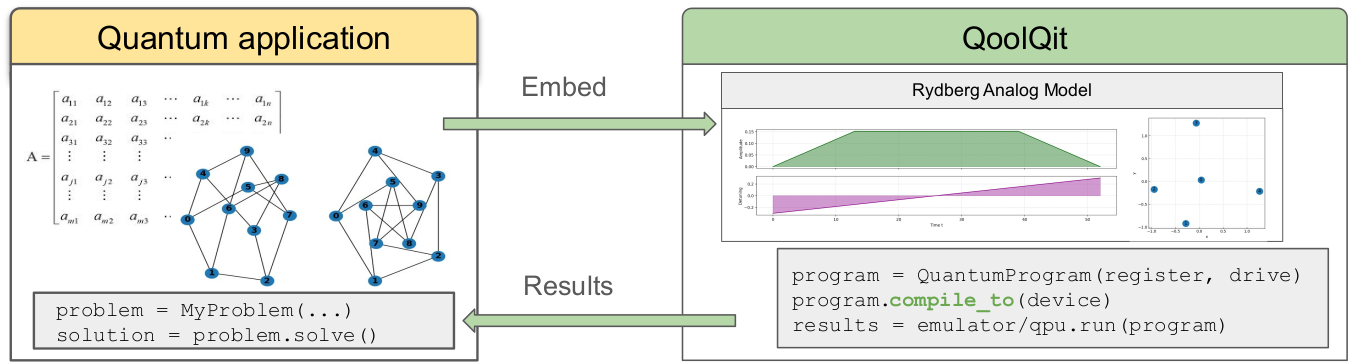

Two available **graph** embedders:
- matrix embedder
- graph to graph embedder

More to come in collaboration with application developers.

### a. Interaction embedder

In [1]:
import numpy as np

Q = np.array([
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
])
Q = Q/Q.max()

InteractionEmbedder:
| Algorithm: interaction_embedding
| Config: InteractionEmbeddingConfig(method='Nelder-Mead', maxiter=200000, tol=1e-08)


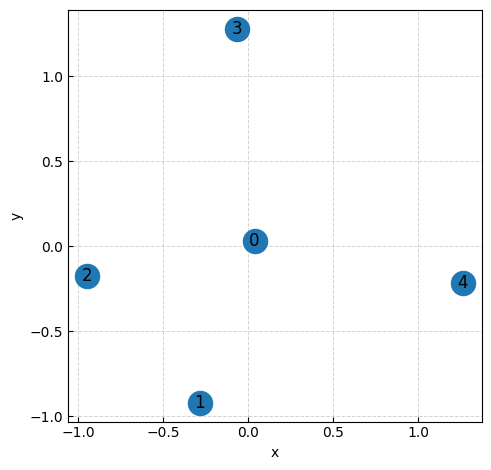

In [2]:
from qoolqit import InteractionEmbedder

embedder = InteractionEmbedder()
print(embedder)

embedded_graph = embedder.embed(Q)
embedded_graph.draw()

### b. SpringLayout Embedder

# 2. Creating a QuantumProgram

After the embedding stage, creating a QuantumProgram is similar to Pulser workflow.

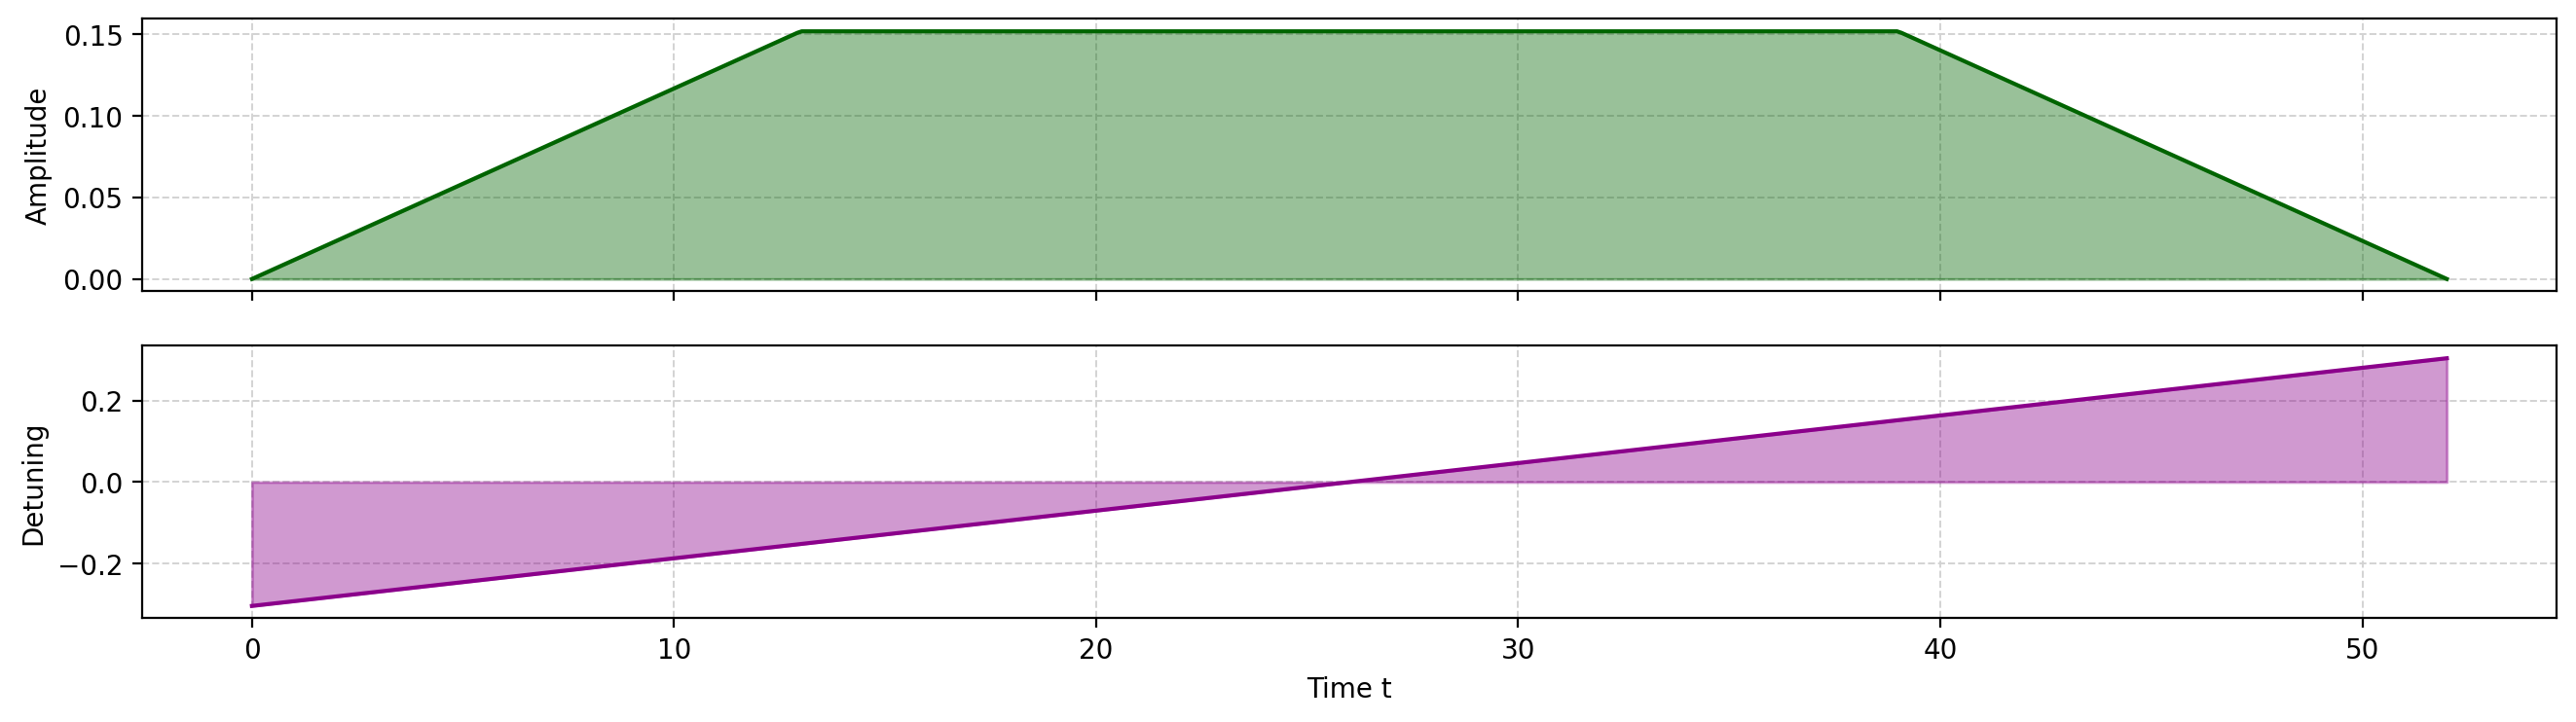

In [3]:
from qoolqit import Drive, PiecewiseLinear, QuantumProgram, Ramp, Register

# Create the register
register = Register.from_graph(embedded_graph)

# Defining the drive
omega = np.median(Q[Q > 0].flatten())
delta_i = -2.0 * omega
delta_f = 2.0 * omega
T = 52.0

amplitude = PiecewiseLinear([T/4, T/2, T/4], [0.0, omega, omega, 0.0])
detuning = Ramp(T, delta_i, delta_f)
drive = Drive(amplitude = amplitude, detuning = detuning)

# Writing the quantum program
program = QuantumProgram(register, drive)
program.draw()

# 3. Compiling to a device

In [4]:
from qoolqit import AnalogDevice

program.compile_to(device = AnalogDevice())# profile=CompilerProfile.MAX_DURATION)

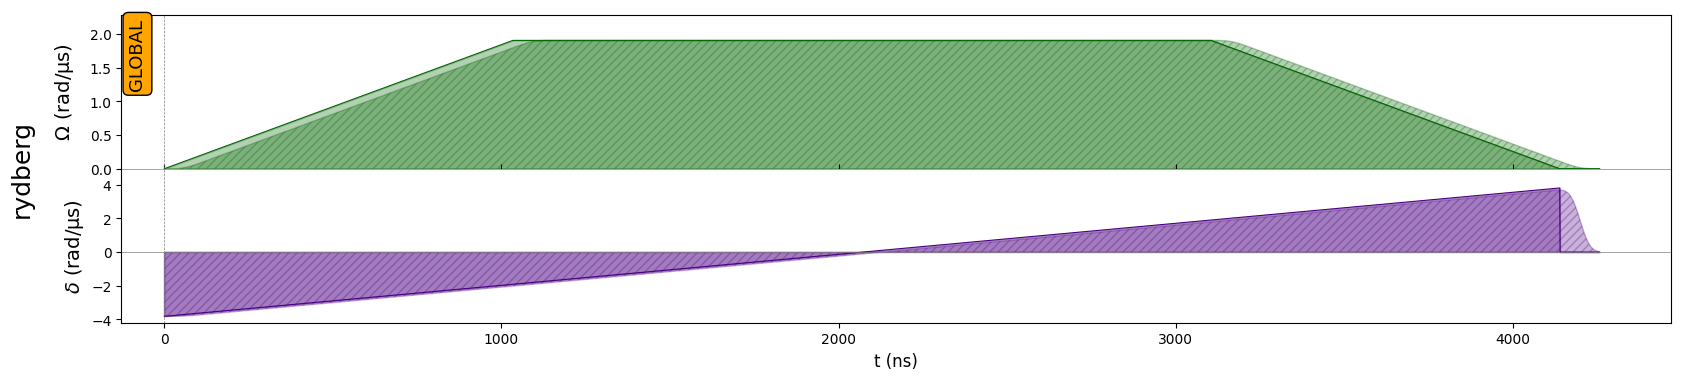

In [5]:
program.compiled_sequence.draw()

## 4. Execution

In [6]:
from qoolqit import LocalEmulator

emulator = LocalEmulator()
results = emulator.run(program)

### a. Configure your emulator

In [ ]:
import os

from pulser.backend import Occupation
from pulser_pasqal import PasqalCloud

from qoolqit import EmulationConfig, RemoteEmulator

connection = PasqalCloud(
        username=os.getenv("PCP_USER"), 
        password=os.getenv("PCP_PASSWORD"), 
        project_id=os.getenv("PCP_PROJECT_ID")
        )

observables = (Occupation(), )
emulation_config = EmulationConfig(observables=observables, with_modulation=True)
emulator = RemoteEmulator(connection=connection, emulation_config=emulation_config)

In [ ]:
# show results